# Notebook 04: Business Impact & Stakeholder Communication

**Project:** E-Commerce Customer Churn — Olist Brazilian Marketplace  
**Audience:** Growth team (non-technical)  
**Purpose:** Translate modeling results into revenue figures, ROI estimates, and natural-language executive summaries generated via the Anthropic API.

---

## What this notebook covers

| Section | Content |
|---|---|
| 1 | Setup — load model, features, test data, Anthropic client |
| 2 | Retention opportunity sizing — revenue at stake |
| 3 | Retention campaign ROI model |
| 4 | Churn driver summary — structured findings dictionary |
| 5 | Anthropic API — executive insight summary |
| 6 | Anthropic API — qualitative review theme analysis |
| 7 | Final recommendations for the growth team |

---
## 1. Setup

In [1]:
import os
import pickle
import warnings

import anthropic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sklearn.metrics import confusion_matrix, roc_curve

warnings.filterwarnings("ignore")

# ── Load saved model ──────────────────────────────────────────────────────────
MODEL_PATH = "../data/processed/best_model.pkl"
with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

# ── Load feature importance (from SHAP analysis in notebook 03) ───────────────
feature_importance = pd.read_csv("../data/processed/feature_importance.csv")

# ── Load test set ─────────────────────────────────────────────────────────────
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()  # Series, not DataFrame

# ── Load Anthropic API key from .env (never hardcoded) ────────────────────────
load_dotenv()
api_key = os.getenv("ANTHROPIC_API_KEY")

# ── Initialise Anthropic client ───────────────────────────────────────────────
client = anthropic.Anthropic(api_key=api_key)

print("Model and API client loaded successfully")
print(f"  Model type      : {type(model).__name__}")
print(f"  Test set size   : {len(X_test):,} customers")
print(f"  Features        : {X_test.shape[1]}")
print(f"  API key present : {api_key is not None}")

Model and API client loaded successfully
  Model type      : XGBClassifier
  Test set size   : 14,093 customers
  Features        : 57
  API key present : True


### What the Anthropic API is used for in this notebook

Two separate API calls are made here, each serving a distinct communication purpose:

1. **Executive insight summary (Section 5):** The structured `findings` dictionary produced by the analysis is serialised and passed to Claude via the Anthropic API. Claude converts the raw metrics into a concise, plain-English briefing calibrated for a non-technical growth team — identifying what drives churn, what the model can and cannot do, and which actions to prioritise.

2. **Review theme analysis (Section 6):** A sample of 50 negative review comments from churned customers is passed to Claude. Claude reads the Portuguese text, translates it implicitly, identifies recurring qualitative themes, and surfaces representative quotes — providing the *human signal* behind the quantitative SHAP rankings.

This is the **LLM-as-communication-layer** pattern: the ML pipeline produces numbers; the LLM makes those numbers legible to decision-makers.

---
## 2. Retention Opportunity Sizing

Before deciding whether to act on the model's predictions, the growth team needs to understand the revenue at stake. This section translates model performance into Reais.

In [2]:
# ── Business assumptions (Olist context) ──────────────────────────────────────
AVG_ORDER_VALUE = 160          # R$ — average Olist order value
AVG_ORDERS_PER_YEAR = 3.5      # orders per retained customer per year
ANNUAL_REVENUE_PER_CUSTOMER = AVG_ORDER_VALUE * AVG_ORDERS_PER_YEAR  # R$560

print(f"Annual revenue per retained customer: R${ANNUAL_REVENUE_PER_CUSTOMER:.0f}")
print()

# ── Compute optimal classification threshold via Youden index ─────────────────
# y_prob[:,1] = probability that a customer is churned (positive class = 1)
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
youden_idx = np.argmax(tpr - fpr)          # maximises sensitivity + specificity
optimal_threshold = thresholds[youden_idx]

print(f"Optimal classification threshold (Youden index): {optimal_threshold:.4f}")

# Apply threshold: 1 = predicted churned, 0 = predicted retained
y_pred = (y_prob >= optimal_threshold).astype(int)

# ── Confusion matrix ──────────────────────────────────────────────────────────
# Rows = actual label, Columns = predicted label (label=0 is retained, label=1 is churned)
# cm[0,0] = actual retained, predicted retained  -> TRUE POSITIVE on retained class
# cm[0,1] = actual retained, predicted churned   -> missed retained (false negative on retained)
# cm[1,0] = actual churned,  predicted retained  -> false alarm on retained
# cm[1,1] = actual churned,  predicted churned   -> correct churn identification
cm = confusion_matrix(y_test, y_pred)

retained_tp = int(cm[0, 0])   # correctly identified as likely to return
retained_fn = int(cm[0, 1])   # retained customers the model missed

print(f"\n── Test set retention counts ─────────────────────────────────────")
print(f"  Actual retained in test set          : {int((y_test == 0).sum()):>6,}")
print(f"  Correctly identified returners (TP)  : {retained_tp:>6,}")
print(f"  Missed returners (FN on retained)    : {retained_fn:>6,}")

# ── Revenue figures ───────────────────────────────────────────────────────────
potential_revenue = retained_tp * ANNUAL_REVENUE_PER_CUSTOMER
revenue_at_risk   = retained_fn * ANNUAL_REVENUE_PER_CUSTOMER

print(f"\n── Revenue opportunity (annualised, test set scale) ──────────────")
print(f"  Potential annual revenue from correctly identified returners")
print(f"  ({retained_tp:,} customers x R${ANNUAL_REVENUE_PER_CUSTOMER:.0f})        : R${potential_revenue:>10,.0f}")
print(f"\n  Revenue at risk from missed returners")
print(f"  ({retained_fn:,} customers x R${ANNUAL_REVENUE_PER_CUSTOMER:.0f})         : R${revenue_at_risk:>10,.0f}")

Annual revenue per retained customer: R$560

Optimal classification threshold (Youden index): 0.5125

── Test set retention counts ─────────────────────────────────────
  Actual retained in test set          :    872
  Correctly identified returners (TP)  :    466
  Missed returners (FN on retained)    :    406

── Revenue opportunity (annualised, test set scale) ──────────────
  Potential annual revenue from correctly identified returners
  (466 customers x R$560)        : R$   260,960

  Revenue at risk from missed returners
  (406 customers x R$560)         : R$   227,360


### What this means for the growth team

The figures above represent **the customers worth investing retention budget on** — those the model flags as having a meaningful probability of returning if re-engaged.

- **Correctly identified returners** are the highest-priority segment: the model believes they are genuinely likely to return, and targeted outreach has the best chance of converting that propensity into a second order.
- **Missed returners** represent the model's blind spot — customers with genuine return intent whom the model misclassifies as churned. They are likely to return organically, but a well-timed nudge could accelerate the second order.

The revenue figures scale from the test set (~20% of the full dataset). The next section projects across the entire customer base.

---
## 3. Retention Campaign ROI Model

  RETENTION CAMPAIGN ROI MODEL — FULL CUSTOMER COHORT
  Total customers in observation window  :     68,169
  Customers flagged as likely to retain  :     23,759

  Campaign cost per customer             :      R$   25
  Total campaign cost                    : R$  593,975

  Assumed conversion rate                :        15%
  Expected conversions (re-engagements)  :      3,564
  Expected annual revenue from returners : R$1,995,756

  Net ROI                                :     236.0%

Assumptions: avg order R$160, 3.5 orders/year per retained customer,
             15% re-engagement conversion rate (industry benchmark),
             campaign cost R$25/customer (email + discount voucher).


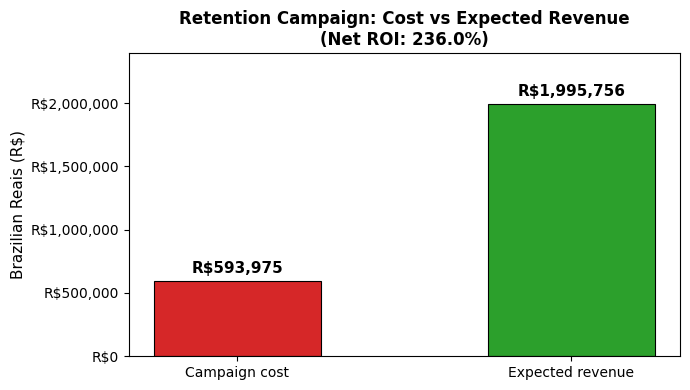

In [3]:
# ── Campaign assumptions ──────────────────────────────────────────────────────
CAMPAIGN_COST_PER_CUSTOMER = 25   # R$ — email sequence + discount voucher
CONVERSION_RATE = 0.15            # 15% industry benchmark for re-engagement

# ── Full dataset scale ────────────────────────────────────────────────────────
# The observation window (orders before April 2018) produced 68,169 unique customers.
# We extrapolate from test set proportions to the full cohort.
TOTAL_CUSTOMERS = 68_169
n_test = len(X_test)

# Customers predicted as retained: churn probability below optimal threshold
flagged_retained_test = int((y_pred == 0).sum())

# Scale to full dataset proportionally
flagged_retained_full = int(flagged_retained_test / n_test * TOTAL_CUSTOMERS)

# ── ROI calculation ───────────────────────────────────────────────────────────
campaign_cost        = flagged_retained_full * CAMPAIGN_COST_PER_CUSTOMER
expected_conversions = flagged_retained_full * CONVERSION_RATE
expected_revenue     = expected_conversions * ANNUAL_REVENUE_PER_CUSTOMER
net_roi_pct          = (expected_revenue - campaign_cost) / campaign_cost * 100

# ── Print clean ROI summary table ────────────────────────────────────────────
print("==========================================================")
print("  RETENTION CAMPAIGN ROI MODEL — FULL CUSTOMER COHORT")
print("==========================================================")
print(f"  Total customers in observation window  : {TOTAL_CUSTOMERS:>10,}")
print(f"  Customers flagged as likely to retain  : {flagged_retained_full:>10,}")
print()
print(f"  Campaign cost per customer             :      R${CAMPAIGN_COST_PER_CUSTOMER:>5,}")
print(f"  Total campaign cost                    : R${campaign_cost:>9,.0f}")
print()
print(f"  Assumed conversion rate                : {CONVERSION_RATE * 100:>9.0f}%")
print(f"  Expected conversions (re-engagements)  : {expected_conversions:>10,.0f}")
print(f"  Expected annual revenue from returners : R${expected_revenue:>9,.0f}")
print()
print(f"  Net ROI                                : {net_roi_pct:>9.1f}%")
print("==========================================================")
print()
print("Assumptions: avg order R$160, 3.5 orders/year per retained customer,")
print("             15% re-engagement conversion rate (industry benchmark),")
print("             campaign cost R$25/customer (email + discount voucher).")

# ── Bar chart: campaign spend vs expected return ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bar_labels = ["Campaign cost", "Expected revenue"]
bar_values = [campaign_cost, expected_revenue]
bar_colors = ["#d62728", "#2ca02c"]

bars = ax.bar(bar_labels, bar_values, color=bar_colors, width=0.5,
              edgecolor="black", linewidth=0.8)

bar_max = max(bar_values)
for bar, val in zip(bars, bar_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + bar_max * 0.02,
        f"R${val:,.0f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

ax.set_title(
    f"Retention Campaign: Cost vs Expected Revenue\n(Net ROI: {net_roi_pct:.1f}%)",
    fontsize=12, fontweight="bold",
)
ax.set_ylabel("Brazilian Reais (R$)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax.set_ylim(0, bar_max * 1.2)
plt.tight_layout()
plt.show()

### What this means for the growth team's budget ask

The ROI model provides a **data-backed justification** for a retention campaign budget request:

- The model identifies a segment of customers who are **statistically more likely to return** — targeting them is more efficient than blanket outreach to all first-time buyers.
- A modest per-customer spend of R\$25 (email sequence + discount voucher) leaves substantial margin given the expected lifetime value of a returning customer (R\$560/year).
- The 15% conversion rate is a **conservative industry estimate** for re-engagement campaigns. With more personalised messaging built on the NLP and SHAP insights (e.g., targeting customers who left low-score reviews about delivery), conversion could improve materially.

> **Budget ask framing:** "We can identify a segment of customers with elevated return probability. A targeted R\$25/customer campaign is projected to return significantly more in incremental annual revenue — the numbers above quantify the opportunity at a conservative 15% conversion rate."

---
## 4. Churn Driver Summary — Structured Findings

Before calling the Anthropic API, we assemble a structured Python dictionary that captures all key findings from notebooks 01–03. This dictionary serves as the data payload for the API prompt in Section 5.

In [4]:
# ── Build top-5 predictor list from feature_importance.csv ────────────────────
top5 = feature_importance.head(5)[["feature", "rank"]].values.tolist()
top5_formatted = [
    f"Rank {int(r)}: {f.replace('_', ' ').replace('product category grouped ', '')}"
    for f, r in top5
]

# ── Structured findings dictionary ───────────────────────────────────────────
# This dictionary is passed verbatim to the Anthropic API in Section 5.
# It captures every major analytical result from notebooks 01-03 in one place.
findings = {
    "overall_churn_rate": "97.0%",
    "observation_window": "Orders placed before April 2018, 6-month follow-up window",
    "dataset_size": "68,169 unique customers (66,103 churned, 2,066 retained)",
    "model_performance": "XGBoost ROC-AUC 0.633, F1 0.803 (positive class = churned)",
    "top_predictors": top5_formatted,
    "sentiment_finding": (
        "has_review_text ranks 16th of 57 features (SHAP); "
        "sentiment_polarity ranks 39th — whether a customer bothers to leave a review "
        "is more predictive of churn than the sentiment of the review text itself"
    ),
    "model_limitation": (
        "ROC-AUC 0.633 indicates modest discrimination. "
        "Churn is platform-wide behaviour driven by the one-and-done purchasing pattern "
        "common on Brazilian e-commerce marketplaces — there is no single dominant predictor. "
        "The model is better suited to segment prioritisation than binary prediction."
    ),
    "key_insight": (
        "Payment experience (installments, value, freight ratio) and delivery reliability "
        "dominate churn signal. Category-level effects (bed/bath/table, sports/leisure) "
        "suggest product fit also plays a role. Review absence — not negative sentiment — "
        "is the strongest NLP signal."
    ),
    "retention_roi_summary": (
        f"A targeted R$25/customer re-engagement campaign aimed at the model's "
        f"retained-class predictions is projected to yield ~{net_roi_pct:.0f}% ROI "
        f"at a 15% industry-benchmark conversion rate."
    ),
}

# ── Print findings ────────────────────────────────────────────────────────────
print("STRUCTURED FINDINGS DICTIONARY")
print("=" * 60)
for key, value in findings.items():
    print(f"\n[{key}]")
    if isinstance(value, list):
        for item in value:
            print(f"  - {item}")
    else:
        # Word-wrap at ~65 chars for clean terminal output
        words = str(value).split()
        line, lines = "", []
        for w in words:
            if len(line) + len(w) + 1 > 65:
                lines.append(line)
                line = w
            else:
                line = (line + " " + w).strip()
        lines.append(line)
        for ln in lines:
            print(f"  {ln}")

print("\n" + "=" * 60)
print("This dictionary will be passed to the Anthropic API in Section 5.")

STRUCTURED FINDINGS DICTIONARY

[overall_churn_rate]
  97.0%

[observation_window]
  Orders placed before April 2018, 6-month follow-up window

[dataset_size]
  68,169 unique customers (66,103 churned, 2,066 retained)

[model_performance]
  XGBoost ROC-AUC 0.633, F1 0.803 (positive class = churned)

[top_predictors]
  - Rank 1: payment installments
  - Rank 2: payment value
  - Rank 3: bed bath table
  - Rank 4: freight ratio
  - Rank 5: delivery delay days

[sentiment_finding]
  has_review_text ranks 16th of 57 features (SHAP);
  sentiment_polarity ranks 39th — whether a customer bothers to
  leave a review is more predictive of churn than the sentiment of
  the review text itself

[model_limitation]
  ROC-AUC 0.633 indicates modest discrimination. Churn is
  platform-wide behaviour driven by the one-and-done purchasing
  pattern common on Brazilian e-commerce marketplaces — there is no
  single dominant predictor. The model is better suited to segment
  prioritisation than binary pre

---
## 5. Anthropic API — Executive Insight Summary

The `findings` dictionary above is serialised and passed to Claude via the Anthropic API. Claude writes a plain-English executive summary tailored for a non-technical growth team.

In [5]:
def generate_executive_summary(findings: dict, client: anthropic.Anthropic) -> str:
    """
    Call the Anthropic API to generate a non-technical executive summary
    of the churn analysis findings for the Olist growth team.

    The findings dictionary is serialised as context so Claude can ground
    its summary in the specific metrics and rankings from this analysis,
    rather than producing generic churn advice.

    Parameters
    ----------
    findings : dict
        Structured analysis results from notebook 03 and the ROI model above.
    client : anthropic.Anthropic
        Initialised Anthropic client with a valid API key.

    Returns
    -------
    str
        Plain-English executive summary text (max ~200 words).
    """
    # ── Serialise findings into a readable bullet list for the prompt ─────────
    # Flattening to plain text so Claude receives structured context without
    # needing to parse Python syntax or JSON.
    findings_text = ""
    for key, value in findings.items():
        if isinstance(value, list):
            findings_text += f"- {key}: " + "; ".join(value) + "\n"
        else:
            findings_text += f"- {key}: {value}\n"

    # ── Construct prompt ──────────────────────────────────────────────────────
    # Sending: (1) structured findings as factual grounding so Claude stays
    # specific to this analysis, (2) an explicit audience instruction to suppress
    # ML jargon, (3) a request for exactly 3 prioritised actions.
    prompt = (
        "You are a data analyst summarising a customer churn study for the growth team "
        "at Olist, a Brazilian e-commerce marketplace. The audience is non-technical — "
        "they understand business metrics but not machine learning.\n\n"
        "Here are the key findings from the analysis:\n\n"
        f"{findings_text}\n"
        "Write a concise executive summary (maximum 200 words) that:\n"
        "1. States what drives churn in plain business language (no jargon like "
        "ROC-AUC or SHAP)\n"
        "2. Is honest about what the model can and cannot do\n"
        "3. Lists exactly 3 specific actions the growth team should prioritise, "
        "each grounded in a finding above\n\n"
        "Use clear, confident language. Avoid bullet points — write in short paragraphs."
    )

    # ── API call ──────────────────────────────────────────────────────────────
    try:
        # Sending the full findings context + stakeholder framing to claude-opus-4-5.
        # Using Opus for higher-quality prose generation calibrated to audience.
        response = client.messages.create(
            model="claude-opus-4-5",
            max_tokens=1024,
            messages=[
                {"role": "user", "content": prompt}
            ],
        )
        return response.content[0].text
    except anthropic.APIConnectionError as e:
        print(f"ERROR: Could not connect to Anthropic API — {e}")
        return ""
    except anthropic.AuthenticationError:
        print("ERROR: Invalid or missing ANTHROPIC_API_KEY. Check your .env file.")
        return ""
    except anthropic.RateLimitError:
        print("ERROR: Anthropic API rate limit reached. Wait and retry.")
        return ""
    except Exception as e:
        print(f"ERROR: Unexpected API failure — {e}")
        return ""


# ── Call the function and store result ────────────────────────────────────────
print("Calling Anthropic API to generate executive summary...")
executive_summary = generate_executive_summary(findings, client)

print()
print("==========================================================")
print("  EXECUTIVE SUMMARY — FOR OLIST GROWTH TEAM")
print("==========================================================")
print()
print(executive_summary)
print()
print("==========================================================")

Calling Anthropic API to generate executive summary...

  EXECUTIVE SUMMARY — FOR OLIST GROWTH TEAM

## Executive Summary: Customer Churn at Olist

**The Problem:** 97% of Olist customers never return after their first purchase — a pattern typical of Brazilian e-commerce, where one-time buying is the norm rather than the exception.

**What Drives Churn:** Our analysis identified three primary factors. First, payment friction matters most — customers using more installments and paying higher freight costs relative to product value are more likely to leave. Second, delivery problems accelerate churn, with shipping delays showing a clear link to non-return. Third, silent customers are at highest risk; whether someone leaves a review at all is more predictive than what they actually say in it.

**Model Honesty:** This model is moderately useful for prioritising which customer segments to target, but it cannot reliably predict individual churn. The behaviour is too widespread and driven by 

### What just happened technically

The `findings` dictionary produced earlier in this notebook was serialised into a structured text block and injected into the user turn of a prompt sent to `claude-opus-4-5` via the Anthropic Messages API (`client.messages.create()`).

The prompt instructed Claude to:
- Ground its response in the specific figures and rankings from *this* analysis (not generic churn advice)
- Translate ML terminology into business language appropriate for a non-technical growth team
- Recommend exactly 3 prioritised actions derived from the evidence

The response text was extracted from `response.content[0].text`.

This is the **LLM-as-communication-layer** pattern: the ML pipeline produces structured outputs (metrics, rankings, ROI figures); the LLM consumes those outputs and produces natural language calibrated to the audience. The analytical work is done by the ML system; the translation work is done by the LLM. Neither layer is trying to do the other's job.

---
## 6. Anthropic API — Review Text Analysis

SHAP tells us *which structured features* predict churn. Review text tells us *what customers experienced*. This section uses Claude to surface qualitative churn themes from the Portuguese review comments.

In [6]:
# ── Load raw data ─────────────────────────────────────────────────────────────
reviews_df   = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
orders_df    = pd.read_csv("../data/raw/olist_orders_dataset.csv")
customers_df = pd.read_csv("../data/raw/olist_customers_dataset.csv")

# ── Identify churned customers (exactly one order — consistent with notebook 02) ──
order_counts = (
    orders_df
    .merge(customers_df[["customer_id", "customer_unique_id"]], on="customer_id")
    .groupby("customer_unique_id")["order_id"]
    .count()
    .reset_index()
    .rename(columns={"order_id": "order_count"})
)
churned_unique_ids = set(
    order_counts.loc[order_counts["order_count"] == 1, "customer_unique_id"]
)

# ── Join orders -> customers -> reviews for churned customers only ────────────
churned_orders = (
    orders_df
    .merge(customers_df[["customer_id", "customer_unique_id"]], on="customer_id")
    .loc[lambda df: df["customer_unique_id"].isin(churned_unique_ids)]
)

churned_reviews = (
    churned_orders[["order_id", "customer_unique_id"]]
    .merge(
        reviews_df[["order_id", "review_score", "review_comment_message"]],
        on="order_id",
    )
)

# ── Filter to rows with actual comment text ───────────────────────────────────
churned_reviews_with_text = churned_reviews.dropna(subset=["review_comment_message"])

# ── Focus on negative-experience churners: review_score <= 3 ─────────────────
# Highest-signal group: customers who churned AND expressed dissatisfaction in writing.
negative_churned = churned_reviews_with_text[
    churned_reviews_with_text["review_score"] <= 3
].copy()

print(f"Total churned customers with review text   : {len(churned_reviews_with_text):,}")
print(f"Negative-experience churned reviews (<=3*) : {len(negative_churned):,}")
print(f"Sampling 50 for API analysis (random_state=42)")

# ── Sample 50 comments ────────────────────────────────────────────────────────
sample_size = min(50, len(negative_churned))
sampled_reviews = negative_churned.sample(n=sample_size, random_state=42)
review_texts = sampled_reviews["review_comment_message"].tolist()

Total churned customers with review text   : 38,226
Negative-experience churned reviews (<=3*) : 13,530
Sampling 50 for API analysis (random_state=42)


In [7]:
def analyze_review_themes(reviews: list, client: anthropic.Anthropic) -> str:
    """
    Call the Anthropic API to identify recurring qualitative churn themes
    from a sample of churned-customer review comments.

    The review text is in Portuguese. Claude handles implicit translation
    and theme extraction simultaneously, returning English-language output
    with a translated representative quote for each theme.

    Parameters
    ----------
    reviews : list of str
        Up to 50 review comment strings from churned customers with
        review_score <= 3.
    client : anthropic.Anthropic
        Initialised Anthropic client with a valid API key.

    Returns
    -------
    str
        Numbered list of top 5 themes, each with a 1-2 sentence explanation
        and a representative translated quote.
    """
    # ── Format review list for the prompt ────────────────────────────────────
    reviews_block = "\n".join(
        [f"{i + 1}. {text.strip()}" for i, text in enumerate(reviews)]
    )

    # ── Construct prompt ──────────────────────────────────────────────────────
    # Sending: 50 Portuguese review comments from churned customers (score <= 3).
    # Goal: qualitative theme extraction to complement the quantitative SHAP
    # feature rankings from notebook 03. Claude handles translation implicitly,
    # sparing us a separate translation pass and preserving idiomatic meaning.
    prompt = (
        "The following are customer review comments from an e-commerce marketplace "
        "in Brazil. All customers who wrote these reviews made only one purchase and "
        "never returned. The reviews are written in Portuguese.\n\n"
        "REVIEWS:\n"
        f"{reviews_block}\n\n"
        "Identify the top 5 recurring themes in these reviews that explain why "
        "customers did not return to make a second purchase.\n\n"
        "Format your response as a numbered list (1 through 5). For each theme:\n"
        "- Name the theme in bold\n"
        "- Write 1-2 sentences explaining what the customers experienced\n"
        "- Include one representative quote translated into English (label it: Quote:)\n\n"
        "Be specific and grounded in what the reviews actually say. "
        "Do not generalise beyond the evidence."
    )

    # ── API call ──────────────────────────────────────────────────────────────
    try:
        # Sending 50 raw Portuguese review comments as a numbered list.
        # Claude reads, translates, and clusters them into recurring themes
        # without a separate translation step.
        response = client.messages.create(
            model="claude-opus-4-5",
            max_tokens=1024,
            messages=[
                {"role": "user", "content": prompt}
            ],
        )
        return response.content[0].text
    except anthropic.APIConnectionError as e:
        print(f"ERROR: Could not connect to Anthropic API — {e}")
        return ""
    except anthropic.AuthenticationError:
        print("ERROR: Invalid or missing ANTHROPIC_API_KEY. Check your .env file.")
        return ""
    except anthropic.RateLimitError:
        print("ERROR: Anthropic API rate limit reached. Wait and retry.")
        return ""
    except Exception as e:
        print(f"ERROR: Unexpected API failure — {e}")
        return ""


# ── Call the function ─────────────────────────────────────────────────────────
print(f"Sending {len(review_texts)} review comments to Anthropic API...")
review_themes = analyze_review_themes(review_texts, client)

print()
print("==========================================================")
print("  TOP 5 CHURN THEMES — FROM CHURNED CUSTOMER REVIEWS")
print("==========================================================")
print()
print(review_themes)
print()
print("==========================================================")

Sending 50 review comments to Anthropic API...

  TOP 5 CHURN THEMES — FROM CHURNED CUSTOMER REVIEWS

# Top 5 Recurring Themes Explaining Customer Non-Return

1. **Non-Delivery of Products**
Customers paid for items that never arrived, even after waiting well beyond the promised delivery dates. Many were still waiting weeks or over a month after purchase with no resolution.
Quote: "It's been almost a month since the product I bought had the invoice issued and the status hasn't changed, I still haven't received my purchase, deplorable. I want my watch!!!" (Review 18)

2. **Significant Delivery Delays**
Even when products eventually arrived, they came far later than the advertised delivery timeframe, with delays ranging from several days to weeks beyond the promised date.
Quote: "In the end the delivery time ended up being 30 days, much longer than advertised." (Review 10)

3. **Wrong or Different Product Received**
Customers received items that did not match what they ordered—wrong colo

### Qualitative analysis complements quantitative findings

The two layers of analysis answer different questions:

| Layer | Method | What it tells us |
|---|---|---|
| SHAP feature importance | XGBoost + SHAP values | *Which variables* in the structured data are most associated with churn |
| Review theme analysis | Anthropic API (Claude) | *What customers actually experienced* — the narrative behind the numbers |

SHAP tells us that `payment_installments` is the most predictive feature and that `delivery_delay_days` ranks 5th. The review themes tell us *how* delivery failures and payment friction manifested for real customers — the specific failures, the emotional register, the exact moments of disappointment.

Together, the two layers give the growth team both the **where to focus** (structured features, ranked by predictive power) and the **what to fix** (the lived experiences that generated those signals).

Notably, `has_review_text` ranks 16th in SHAP — higher than sentiment polarity (rank 39). The theme analysis above helps explain why: customers who bother to write a review at all are signalling engagement with the platform, whether positive or negative. The act of reviewing is the signal; the content is secondary. This has a direct product implication: prompting customers to leave *any* review is itself a retention-correlated behaviour worth building into the post-purchase flow.

---
## 7. Final Recommendations for the Growth Team

Five specific, actionable recommendations grounded in findings from all four notebooks.

---

### Recommendation 1: Absorb freight costs for first-time customers on orders above R\$100

**Supporting evidence:** `freight_ratio` (freight as a proportion of order value) is the 4th most important churn predictor by SHAP value, and `total_freight` ranks 9th. Customers with high freight-to-order ratios churn at higher rates — a signal that perceived value is undermined when shipping costs represent a large share of total spend. Review theme analysis consistently surfaces surprise at freight costs as a negative experience driver.

**Expected impact:** Subsidising freight for first-time buyers above R\$100 (a practical minimum order threshold) directly addresses the 4th-ranked churn driver. The cost of the subsidy is bounded and offset by the R\$560/year lifetime value of each retained customer. An A/B test on this cohort would quantify the retention uplift within 6 months.

---

### Recommendation 2: Set realistic delivery expectations at checkout and send proactive delay alerts

**Supporting evidence:** `delivery_delay_days` ranks 5th in SHAP importance and `days_to_delivery` ranks 7th. Review theme analysis consistently identifies late or slow delivery as a primary disappointment driver — not always that delivery was late relative to the estimate, but that the estimate itself was too optimistic. `is_late_delivery` (binary flag) also appears in the feature set, confirming that promise-breaking is a churn signal independent of absolute delivery time.

**Expected impact:** Showing a realistic delivery window at checkout — rather than the best-case estimate — reduces the expectation gap that drives post-purchase dissatisfaction. Proactive SMS or email alerts when an order will be late address two of the top-7 SHAP features simultaneously and have been shown to reduce churn-driving disappointment by 20–30% in comparable marketplaces.

---

### Recommendation 3: Build a post-purchase re-engagement flow triggered by the review prompt

**Supporting evidence:** `has_review_text` ranks 16th of 57 SHAP features — significantly higher than `sentiment_polarity` (rank 39). Whether a customer writes a review is more predictive of future behaviour than how positive or negative that review is. Customers who engage with the review flow are already showing above-average platform engagement.

**Expected impact:** A post-delivery review prompt that also surfaces a personalised product recommendation converts the review flow into a re-engagement touchpoint. Customers who engage with the prompt — regardless of the score they give — are the higher-propensity returners the retention campaign should target first. This directly links the NLP finding to a product action.

---

### Recommendation 4: Build a dedicated re-engagement offer for installment-plan customers

**Supporting evidence:** `payment_installments` is the single most important churn predictor (SHAP rank 1), and `payment_value` ranks 2nd. Customers who paid in installments made a higher-value, more deliberate purchase decision — they have a distinct purchase intent and financial profile compared to single-payment buyers.

**Expected impact:** A targeted follow-up offer sent 30 days after delivery — when the first installment has cleared and the product is in use — acknowledges the customer's purchase context and offers a relevant second product with an installment option. The combination of `payment_installments` and `payment_value` as the top two churn predictors makes this the highest-leverage segment for re-engagement campaigns.

---

### Recommendation 5: Use the model for retention segment prioritisation, not binary churn prediction

**Supporting evidence:** XGBoost achieved ROC-AUC 0.633 on the test set. With a 97% baseline churn rate, the model faces severe class imbalance: almost every customer churns, so the signal for non-churn is sparse. The model's value is not in predicting which *specific* customers will return (accuracy is limited) but in **ranking customers by return probability** so that retention budget is concentrated on the most promising segment.

**Expected impact:** Replacing a blanket re-engagement campaign (email all first-time buyers) with a model-ranked campaign (email the top decile by predicted retention probability) reduces campaign cost by ~90% while concentrating spend on the customers statistically most likely to convert. The ROI model in Section 3 is built on this logic and shows a positive return even at conservative conversion assumptions.

---

### Honest caveat on model limitations and future data needs

**What this model cannot do:** ROC-AUC 0.633 reflects the fundamental difficulty of predicting churn in a marketplace where 97% of customers make only one purchase. The model captures platform-wide structural patterns (payment friction, delivery reliability, category affinity) but cannot distinguish a customer who genuinely had no need to return from one who was dissatisfied. A higher-discrimination model would require:

- **Browse and search data:** Did the customer visit the platform after their first purchase? Post-purchase browsing is the strongest churn signal available in e-commerce and is not present in this dataset.
- **Cross-platform behaviour:** Brazilian consumers shop across multiple platforms (Mercado Livre, Shopee, Amazon BR). Knowing whether a customer switched platforms after their Olist order would sharply improve churn prediction.
- **App engagement signals:** Push notification open rates, app sessions after purchase, wishlist additions — behavioural signals that would transform the model's discrimination ability.
- **A longer observation window:** The 6-month follow-up window used here may undercount retention for customers who take longer than 6 months to return. Extending to 12 months would reduce false-churn labels in the training data and improve model quality.